In [1]:
import pandas as pd
import matplotlib as plt
from pyvis import network as net
import networkx as nx

# toon alle columns
pd.set_option('display.max_columns', None)

In [ ]:
#lees de excel sheets in
st=pd.read_excel("inputs/Studentgegevens.xlsx", sheet_name='Studenten',usecols=['OBJID','GBDATUM','GBLND'])
ins1=pd.read_excel("inputs/Studentgegevens.xlsx", sheet_name='Inschrijvingen HO 1',usecols=['OBJID','TABNR'])
ins2=pd.read_excel("inputs/Studentgegevens.xlsx", sheet_name='Inschrijvingen HO 2')
stube1=pd.read_excel("inputs/Studentgegevens.xlsx", sheet_name='Studiebewijzen 1',usecols=['OBJID','TABNR'])
stube2=pd.read_excel("inputs/Studentgegevens.xlsx", sheet_name='Studiebewijzen 2')

In [3]:
st_ins1=st.merge(ins1,left_on='OBJID',right_on='OBJID',validate="1:1")
st_ins2=st_ins1.merge(ins2,left_on='TABNR',right_on='TABNR',validate='1:m')
st_ins2=st_ins2.drop(['TABNR'],axis=1)
st_ins2


,OBJID,GBDATUM,GBLND,TABSEQNR,ACADEMIEJAAR,INSTELLING,INSCHRIJVINGSDATUM,UITSCHRIJVINGSDATUM,OPLEIDINGSVARIETEIT,SOORT_OPLEIDING,INSCHRIJVINGSSTATUS
0,600000,19900907,PT,2,2015,110131,03.07.2015,NaN,6069.0,Doctoraatsopleiding,1
1,600000,19900907,PT,5,2017,110131,05.10.2017,NaN,6069.0,Doctoraatsopleiding,1
2,600000,19900907,PT,3,2016,110131,15.07.2016,NaN,6069.0,Doctoraatsopleiding,1
3,600000,19900907,PT,1,2014,110131,23.01.2015,NaN,6069.0,Doctoraatsopleiding,1
4,600000,19900907,PT,6,2018,110131,28.03.2019,NaN,6068.0,Academische graad van doctor,1
...,...,...,...,...,...,...,...,...,...,...,...
10072,603981,19670502,BE,4,2006,103622,11.09.2006,NaN,999168.0,Licentie,1
10073,603981,19670502,BE,2,2005,103622,12.09.2005,NaN,999168.0,Licentie,1
10074,603981,19670502,BE,5,2004,103622,13.09.2004,NaN,999170.0,Licentie,1
10075,603981,19670502,BE,3,2014,103622,17.10.2014,NaN,6026.0,Postgraduaat,1


In [4]:
st_stube1=st.merge(stube1,left_on='OBJID',right_on='OBJID',validate="1:1")
## de mappingtabel van "studiebewijzen 1" bevat nulls voor TABNR
st_stube1=st_stube1.dropna(subset=['TABNR'])
st_stube2=st_stube1.merge(stube2,left_on='TABNR',right_on='TABNR',how='left',validate='1:m')
# drop row LAND, is altijd 'BEL'
st_stube2=st_stube2.drop(['TABNR','TABSEQNR','LAND'],axis=1)
# drop rows met AUTHENTICITEIT='Eigen verklaring - O' , is onvolledige data
st_stube2=st_stube2[st_stube2.AUTHENTICITEIT=='Authentiek']
# normaliseer schooltype naar lowercase
st_stube2['SCHOOLTYPE']=st_stube2['SCHOOLTYPE'].str.lower()
# normaliseer TAAL naar lowercase
st_stube2['TAAL']=st_stube2['TAAL'].str.lower()
# normaliseer SPECIALISATIE_CODE naar lowercase
st_stube2['SPECIALISATIE_CODE']=st_stube2['SPECIALISATIE_CODE'].str.upper()
st_stube2

,OBJID,GBDATUM,GBLND,INSTELLING_NAAM,INSTELLING_NUMMER,SCHOOLTYPE,STUDIERICHTING_CODE,STUDIERICHTING_NAAM,SPECIALISATIE_CODE,SPECIALISATIE_NAAM,LEV_NAAM,AUTHENTICITEIT,CATEGORIE,GRAAD,ONDERWIJSVORM,BEWIJSTYPE,BEWIJSSTAAT,INSTANTIE,ONDERWERP,UITREIKINGSDATUM,TAAL
0,600000,19900907,PT,Katholieke Universiteit Leuven,110131.0,niet van toepassing,6068,academische graad van doctor,NaN,NaN,Hoger onderwijs,Authentiek,Hoger onderwijs,Doctor,Niet van toepassing,Diploma,Eindbewijs,Universiteit,Niet gespecificeerd,03.05.2019,und
1,600000,19900907,PT,Mobyus - Centrum voor Volwassenenonderwijs,32888.0,gewoon,70000417,NT2 - Breakthrough publiek,NaN,NaN,Volwassenenonderwijs,Authentiek,Secundair onderwijs,Niet van toepassing,Niet van toepassing,Deelcertificaat,Tussenbewijs,Centrum voor Volwass,Nederlands voor anderstaligen,22.05.2017,nld
2,600000,19900907,PT,Mobyus - Centrum voor Volwassenenonderwijs,32888.0,gewoon,70000414,NT2 - Breakthrough persoonlijk,NaN,NaN,Volwassenenonderwijs,Authentiek,Secundair onderwijs,Niet van toepassing,Niet van toepassing,Deelcertificaat,Tussenbewijs,Centrum voor Volwass,Nederlands voor anderstaligen,22.05.2017,nld
3,600000,19900907,PT,Mobyus - Centrum voor Volwassenenonderwijs,32888.0,gewoon,830,Nederlands tweede taal - richtgraad 1,NaN,NaN,Volwassenenonderwijs,Authentiek,Secundair onderwijs,Niet van toepassing,Niet van toepassing,Certificaat,Eindbewijs,Centrum voor Volwass,Nederlands voor anderstaligen,23.05.2018,nld
4,600000,19900907,PT,Mobyus - Centrum voor Volwassenenonderwijs,32888.0,gewoon,70000423,NT2 - Waystage schriftelijk,NaN,NaN,Volwassenenonderwijs,Authentiek,Secundair onderwijs,Niet van toepassing,Niet van toepassing,Deelcertificaat,Tussenbewijs,Centrum voor Volwass,Nederlands voor anderstaligen,23.05.2018,nld
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9357,603976,19720111,BE,Centrum voor Volwassenenonderwijs De Oranjerie,125468.0,niet van toepassing,40009253,Groepsmanagement OP,NaN,NaN,Volwassenenonderwijs,Authentiek,Hoger onderwijs,Niet van toepassing,Niet van toepassing,Deelcertificaat,Tussenbewijs,Centrum voor Volwass,Lerarenopleiding andere b,20.01.2015,nld
9358,603976,19720111,BE,Centrum voor Volwassenenonderwijs De Oranjerie,125468.0,niet van toepassing,70000317,Praktijk P6,NaN,NaN,Volwassenenonderwijs,Authentiek,Hoger onderwijs,Niet van toepassing,Niet van toepassing,Deelcertificaat,Tussenbewijs,Centrum voor Volwass,Niet gespecificeerd,21.01.2015,nld
9359,603976,19720111,BE,Centrum voor Volwassenenonderwijs De Oranjerie,125468.0,niet van toepassing,70000316,Praktijk P5,NaN,NaN,Volwassenenonderwijs,Authentiek,Hoger onderwijs,Niet van toepassing,Niet van toepassing,Deelcertificaat,Tussenbewijs,Centrum voor Volwass,Niet gespecificeerd,21.01.2015,nld
9360,603976,19720111,BE,LUCA School of Arts,103622.0,niet van toepassing,34555,Audiovisuele technieken: fotografie,NaN,NaN,Hoger onderwijs,Authentiek,Hoger onderwijs,Professionele bachel,Niet van toepassing,Diploma,Eindbewijs,Hogeschool,Fotografie,23.06.2016,nld


In [4]:
pd.unique(st_stube2[['GBLND']].values.ravel())


array(['PT', 'CN', 'RU', 'GR', 'NL', 'BE', 'RO', 'MX', 'FR', 'CO', 'IT',
       'US', 'KE', 'CM', 'PH', 'DE', 'TZ', 'CH', 'UA', 'PL', 'ES', 'CA',
       'ZA', 'BR', 'IN', 'CU', 'MA', 'RS', 'PS', 'AU', 'AE', 'CL', 'KR',
       'EC', 'AL', 'BG', 'YU', 'EG', 'BI', 'GH', 'RW', 'UG', 'NG', 'SI',
       'GB', 'TR', 'TV', 'VN', 'AR', 'KZ', 'CD', 'TH', 'MU', 'PE', 'AT',
       'ID', 'AM', 'CZ', 'BO', 'NP', 'BD', 'DK', 'IR', 'KG', 'LT', 'JO',
       'MY', 'LS', 'LB', 'ZW', 'MD', 'GE', 'IE', 'SY', 'SO', 'AO', 'SV',
       'IQ', 'TW', 'HT', 'JP', 'BA', 'PK', 'AF', 'SR', 'HK', 'VE', 'HU',
       'FI', 'SG', 'HR', 'CY', 'MK', 'CS', 'AZ'], dtype=object)

In [5]:
uniqs = pd.unique(st_stube2[['STUDIERICHTING_CODE']].values.ravel()).size
# same as len(st_stube2['STUDIERICHTING_CODE'].drop_duplicates())
uniqs_names = len(st_stube2['STUDIERICHTING_NAAM'].drop_duplicates())
uniqs, uniqs_names

(1552, 1303)

In [6]:
dupls = len(st_stube2['STUDIERICHTING_CODE'])-len(st_stube2['STUDIERICHTING_CODE'].drop_duplicates())
dupls_names = len(st_stube2['STUDIERICHTING_NAAM'])-len(st_stube2['STUDIERICHTING_NAAM'].drop_duplicates())
dupls, dupls_names

(5658, 5907)

In [44]:
totls = len(st_stube2['STUDIERICHTING_CODE'])
# same as len(st_stube2['STUDIERICHTING_NAAM'])
totls

7210

In [7]:
uniqs != uniqs_names
# WTF?

True

<Axes: ylabel='count'>

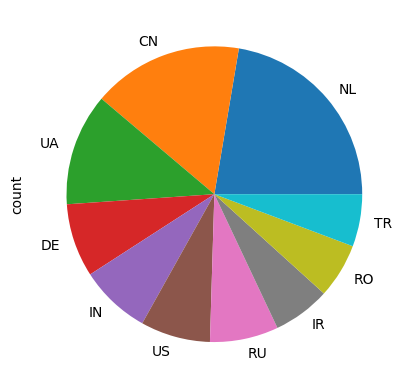

In [37]:
df = st_stube2[st_stube2['GBLND'] != 'BE']
country_counts = df['GBLND'].value_counts().nlargest(10)
#print(country_counts)
country_counts.plot.pie(x=st_stube2['GBLND'], y=country_counts)
